# Fine-Tuning von TinyBERT für die Klassifikation von Netzwerk-Traffic
Dieses Jupyter Notebook dokumentiert den gesamten Prozess des Fine-Tunings eines `TinyBERT`-Modells zur Klassifizierung von Netzwerk-Flow-Daten. Das Ziel ist es, verschiedene Arten von Netzwerkangriffen anhand von aggregierten Flow-Merkmalen zu erkennen.

Der Prozess umfasst die folgenden Schritte:,
1.  **Setup und Konfiguration:** Laden der notwendigen Bibliotheken und Definieren aller Pfade und Hyperparameter.
2.  **Datenvorbereitung:** Erstellen einer benutzerdefinierten `Dataset`-Klasse und Laden der vorverarbeiteten Text- und Label-Daten.
3.  **Modell-Setup und Loss-Funktion:** Laden des vortrainierten `TinyBERT`-Modells und Implementierung von Strategien (z.B. Weighted Loss) zum Umgang mit unausgeglichenen Datensätzen.
4.  **Dataset-Erstellung und Trainer-Setup:** Instanziierung der Datasets und Konfiguration des `Hugging Face Trainers`.
5.  **Hyperparameter-Optimierung:** Automatische Suche nach den besten Hyperparametern mit `Optuna`
6.  **Training des finalen Modells:** Durchführung des finalen Trainings mit den optimierten Parametern.
7.  **Evaluation und Analyse:** Umfassende Bewertung des Modells anhand von Metriken, `classification_report` und `confusion matrix`.
8.  **Speichern des Modells:** Sichern des finalen Modells, des Tokenizers und der Ergebnisse für die spätere Verwendung.
    

## 1. Setup und Konfiguration

In diesem Abschnitt werden alle notwendigen Vorbereitungen getroffen:
- Importieren der erforderlichen Bibliotheken (wie PyTorch, Hugging Face Transformers, Pandas, etc.).
- Einrichten der GPU-Nutzung für beschleunigtes Training.
- Import einer benutzerdefinierten Modell-Architektur (`TinyBertWithGAP`).

In [1]:
%pip install -r requirements.txt


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'
Note: you may need to restart the kernel to use updated packages.


In [2]:
from tinybert_with_gap import TinyBertWithGAP

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
"""%pip uninstall torch torchvision torchaudio transformers -y
%pip cache purge
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
%pip install transformers

"""

'%pip uninstall torch torchvision torchaudio transformers -y\n%pip cache purge\n%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118\n%pip install transformers\n\n'

In [4]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [5]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    TrainingArguments, 
    DataCollatorWithPadding
)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import logging
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Logging Setup
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Device Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

2025-11-25 17:54:38.585123: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Using device: cuda
GPU: NVIDIA GeForce RTX 3090
GPU Memory: 23.6 GB


### 1.1 Pfade und Hyperparameter

Die `CONFIG`-Variable speichert alle zentralen Einstellungen an einem Ort. Dies erleichtert die Anpassung und Reproduzierbarkeit von Experimenten. Die hier eingetragenen Hyperparameter (`LEARNING_RATE`, `BATCH_SIZE` etc.) sind das Ergebnis der Hyperparameter-Optimierung aus Abschnitt 5.


In [17]:
# Konfiguration - Passe diese Werte an deine Bedürfnisse an
CONFIG = {
    'MODEL_NAME': "huawei-noah/TinyBERT_General_4L_312D",  # TinyBERT Model
    'Train_DATA_CSV_PATH': "../data/train/bert_train_sequences_v8.csv",
    'Train_LABELS_CSV_PATH': "../data/train/y_train_resampled_attackCategoryEncoded.csv",               # Pfad zu deinen Labels
    'Eval_LABELS_CSV_PATH': "../data/test/y_test_Attack_Category_Encoded.csv",               # Pfad zu deinen Labels
    'Eval_DATA_CSV_PATH': "../data/test/bert_test_sequences_no_sep_v8.csv",
    'LABEL_COLUMN_TRAIN': 'attackCategoryEncoded',
    'LABEL_COLUMN_TEST': 'Attack_Category_Encoded',            # Spalte mit den encodeten Labels
    'OUTPUT_DIR': "../model/tinybert_finetuned_final_GAP_no_sep",
    'MAX_LENGTH': 192,                                      # Anpassen basierend auf deiner Datenlänge
    'BATCH_SIZE': 16,                                       # Reduzieren falls Speicher-Probleme
    'LEARNING_RATE': 0.00004998985438779802,
    'NUM_EPOCHS': 4,
    'TEST_SIZE': 0.2,
    'RANDOM_STATE': 42
}


print("Konfiguration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Konfiguration:
  MODEL_NAME: huawei-noah/TinyBERT_General_4L_312D
  Train_DATA_CSV_PATH: ../data/train/bert_train_sequences_v8.csv
  Train_LABELS_CSV_PATH: ../data/train/y_train_resampled_attackCategoryEncoded.csv
  Eval_LABELS_CSV_PATH: ../data/test/y_test_Attack_Category_Encoded.csv
  Eval_DATA_CSV_PATH: ../data/test/bert_test_sequences_no_sep_v8.csv
  LABEL_COLUMN_TRAIN: attackCategoryEncoded
  LABEL_COLUMN_TEST: Attack_Category_Encoded
  OUTPUT_DIR: ../model/tinybert_finetuned_final_GAP_no_sep
  MAX_LENGTH: 192
  BATCH_SIZE: 16
  LEARNING_RATE: 4.998985438779802e-05
  NUM_EPOCHS: 4
  TEST_SIZE: 0.2
  RANDOM_STATE: 42


## 2. Datenvorbereitung

Dieser Abschnitt behandelt das Laden und die Vorbereitung der Daten für das Training.

Zuerst definieren wir eine `NetworkFlowDataset`-Klasse, die von `torch.utils.data.Dataset` erbt. Sie kümmert sich um die Tokenisierung der Textdaten und formatiert jeden Eintrag passend für das BERT-Modell (inkl. `input_ids`, `attention_mask` und `labels`).

In [7]:
class NetworkFlowDataset(Dataset):
    """Custom Dataset für Netzwerk Flow Daten"""
    
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Tokenisierung
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

print("Dataset Klasse definiert.")

Dataset Klasse definiert.


### 2.1 Daten laden und analysieren

Hier laden wir die Trainings- und Testdaten und führen eine kurze explorative Analyse durch.

Die Visualisierung der Label-Verteilung im Trainingsdatensatz ist entscheidend. Sie zeigt, ob die Klassen ausgeglichen sind oder ob eine Unausgeglichenheit (Class Imbalance) vorliegt. Wie die Ergebnisse zeigen, sind die Daten perfekt ausbalanciert, was auf ein vorheriges Resampling (z.B. durch SMOTE oder zufälliges Oversampling) hindeutet. Dennoch behalten wir den Code für die Gewichtungsberechnung bei, falls das Notebook mit unausgeglichenen Daten verwendet wird.


In [18]:
def load_and_prepare_data(data_csv_path, labels_csv_path, label_column):
    """
    Lädt und bereitet die Daten vor
    
    Args:
        data_csv_path: Pfad zur CSV mit den Trainingsdaten
        labels_csv_path: Pfad zur CSV mit den Labels
        label_column: Name der Spalte mit den encodeten Labels
    
    Returns:
        texts, labels: Vorbereitete Texte und Labels
    """
    logger.info("Lade Daten...")
    
    # Daten laden
    data_df = pd.read_csv(data_csv_path, sep='\t', encoding='utf-8')
    labels_df = pd.read_csv(labels_csv_path, sep='\t', encoding='utf-8')
    
    logger.info(f"Daten shape: {data_df.shape}")
    logger.info(f"Labels shape: {labels_df.shape}")
    logger.info(f"Labels shape: {labels_df.columns}")
    
    # Überprüfe ob die Anzahl der Zeilen übereinstimmt
    if len(data_df) != len(labels_df):
        raise ValueError(f"Anzahl der Datenzeilen ({len(data_df)}) stimmt nicht mit Anzahl der Labels ({len(labels_df)}) überein!")
    
    # Annahme: die erste Spalte in data_df enthält die formatierten Texte
    texts = data_df.iloc[:, 0].tolist()
    
    # Labels aus der spezifizierten Spalte laden (bereits encoded)
    if label_column not in labels_df.columns:
        raise ValueError(f"Label Spalte '{label_column}' nicht in den Label-Daten gefunden!")
    
    labels = labels_df[label_column].values
    
    logger.info(f"Anzahl unique Labels: {len(np.unique(labels))}")
    logger.info(f"Label Bereich: {np.min(labels)} - {np.max(labels)}")
    
    return texts, labels

# Daten laden
train_texts, train_labels = load_and_prepare_data(
    CONFIG['Train_DATA_CSV_PATH'], 
    CONFIG['Train_LABELS_CSV_PATH'], 
    CONFIG['LABEL_COLUMN_TRAIN']
)
val_texts, val_labels = load_and_prepare_data(
    CONFIG['Eval_DATA_CSV_PATH'], 
    CONFIG['Eval_LABELS_CSV_PATH'], 
    CONFIG['LABEL_COLUMN_TEST']
)
print(f"\nDaten erfolgreich geladen:")
print(f"Anzahl Samples: {len(train_texts)}")
print(f"Anzahl unique Labels: {len(np.unique(train_labels))}")

INFO:__main__:Lade Daten...
INFO:__main__:Daten shape: (2000000, 1)
INFO:__main__:Labels shape: (2000000, 1)
INFO:__main__:Labels shape: Index(['attackCategoryEncoded'], dtype='object')
INFO:__main__:Anzahl unique Labels: 10
INFO:__main__:Label Bereich: 0 - 9
INFO:__main__:Lade Daten...
INFO:__main__:Daten shape: (473085, 1)
INFO:__main__:Labels shape: (473085, 3)
INFO:__main__:Labels shape: Index(['Attack', 'Label', 'Attack_Category_Encoded'], dtype='object')
INFO:__main__:Anzahl unique Labels: 10
INFO:__main__:Label Bereich: 0 - 9



Daten erfolgreich geladen:
Anzahl Samples: 2000000
Anzahl unique Labels: 10


Label Verteilung:
  Label 0: 200000 (10.0%)
  Label 1: 200000 (10.0%)
  Label 2: 200000 (10.0%)
  Label 3: 200000 (10.0%)
  Label 4: 200000 (10.0%)
  Label 5: 200000 (10.0%)
  Label 6: 200000 (10.0%)
  Label 7: 200000 (10.0%)
  Label 8: 200000 (10.0%)
  Label 9: 200000 (10.0%)


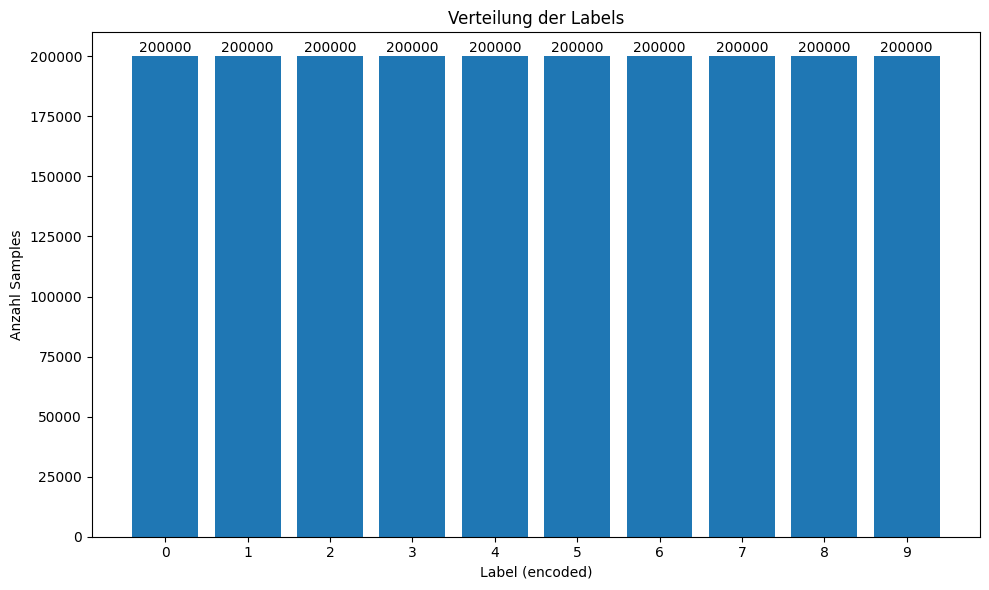


Beispiel Text (erste 300 Zeichen):
Text: [CLS] dstToSrcAvgThroughput: 0.49 dstToSrcIatAvg: 0.57 dstToSrcSecondBytes: 0.04 inBytes: 0.39 inPkts: 0.23 longestFlowPkt: 0.81 minIpPktLen: 0.57 numPkts128To256Bytes: 0.19 outBytes: 0.42 retransmittedInBytes: 0.34 shortestFlowPkt: 0.35 srcToDstSecondBytes: 0.05 l7Proto: 109 dnsQueryType: 0 icmpIpv...
Label: 0

Text Längen Statistiken:
  Durchschnitt: 314.2
  Median: 314.0
  Min: 312
  Max: 316
  95. Perzentil: 316.0


In [19]:
# Daten Exploration
print("Label Verteilung:")
label_counts = Counter(train_labels)
weights =[]
for label, count in sorted(label_counts.items()):
    percentage = count / len(train_labels) * 100
    class_weight = len(train_labels) / count
    weights.append(class_weight)
    print(f"  Label {label}: {count} ({percentage:.1f}%)")

# Visualisierung der Label Verteilung
plt.figure(figsize=(10, 6))
labels_unique, counts = np.unique(train_labels, return_counts=True)
plt.bar(labels_unique, counts)
plt.xlabel('Label (encoded)')
plt.ylabel('Anzahl Samples')
plt.title('Verteilung der Labels')
plt.xticks(labels_unique)
for i, count in enumerate(counts):
    plt.text(labels_unique[i], count + max(counts)*0.01, str(count), ha='center')
plt.tight_layout()
plt.show()

# Beispiel Text anzeigen
print(f"\nBeispiel Text (erste 300 Zeichen):")
print(f"Text: {train_texts[0][:300]}...")
print(f"Label: {train_labels[0]}")

# Text Längen Statistiken
text_lengths = [len(text) for text in train_texts]
print(f"\nText Längen Statistiken:")
print(f"  Durchschnitt: {np.mean(text_lengths):.1f}")
print(f"  Median: {np.median(text_lengths):.1f}")
print(f"  Min: {np.min(text_lengths)}")
print(f"  Max: {np.max(text_lengths)}")
print(f"  95. Perzentil: {np.percentile(text_lengths, 95):.1f}")

## 3. Modell-Setup und Loss-Funktion

Hier konfigurieren wir die Modellarchitektur und die Strategie zum Umgang mit den Daten.

- **Tokenizer und Modell:** Wir laden den `AutoTokenizer` passend zum `TinyBERT`-Modell und unsere benutzerdefinierte `TinyBertWithGAP`-Architektur. `TinyBertWithGAP` erweitert das Standard-Modell um eine Global Average Pooling (GAP) Schicht, die oft eine robustere Alternative zum einfachen `[CLS]`-Token für Klassifikationsaufgaben darstellt.
- **Umgang mit Klassen-Imbalance:** Obwohl unsere aktuellen Daten ausgeglichen sind, ist der Code zur Behandlung von unausgeglichenen Datensätzen ein wichtiger Bestandteil des Notebooks.

In [20]:



# Tokenizer laden
print("Lade Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(CONFIG['MODEL_NAME'])

# Falls [CLS] und [SEP] Tokens nicht im Tokenizer sind, füge sie hinzu
special_tokens_dict = {}
if '[CLS]' not in tokenizer.vocab:
    special_tokens_dict['cls_token'] = '[CLS]'
if '[SEP]' not in tokenizer.vocab:
    special_tokens_dict['sep_token'] = '[SEP]'

if special_tokens_dict:
    tokenizer.add_special_tokens(special_tokens_dict)
    print(f"Added special tokens: {special_tokens_dict}")

print(f"Tokenizer Vocab Size: {len(tokenizer)}")

# Model für Klassifikation
num_labels = len(np.unique(train_labels))
print(f"\nLade Model mit {num_labels} Labels...")
model = TinyBertWithGAP(
    CONFIG['MODEL_NAME'], 
    num_labels=num_labels,
    torch_dtype="auto"
)

# Model Tokenizer Größe anpassen falls nötig
if len(special_tokens_dict) > 0:
    model.resize_token_embeddings(len(tokenizer))
    print("Model Embeddings angepasst für neue Tokens")

model.to(device)
print(f"Model geladen und auf {device} verschoben")

# Model Info
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel Parameter:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")

Lade Tokenizer...
Tokenizer Vocab Size: 30522

Lade Model mit 10 Labels...


`torch_dtype` is deprecated! Use `dtype` instead!


Model geladen und auf cuda verschoben

Model Parameter:
  Total: 14,353,378
  Trainable: 14,353,378


### 3.1 Custom Trainer für Weighted Loss

Um bei unausgeglichenen Daten eine robuste Leistung zu gewährleisten, ist eine gewichtete Loss-Funktion eine gängige Strategie. Wir definieren eine `WeightedTrainer`-Klasse, die von `transformers.Trainer` erbt.

- **`WeightedTrainer`:** Diese Klasse überschreibt die `compute_loss`-Methode. Sie übergibt die Klassengewichte (`imbalance_weights`) an die `CrossEntropyLoss`-Funktion. Dadurch werden Fehler bei der Klassifizierung von seltenen Klassen stärker bestraft, was das Modell zwingt, diese nicht zu ignorieren.
- **`FocalLossTrainer` (Alternative):** Zusätzlich wird eine `FocalLossTrainer`-Klasse als alternative Strategie definiert. Focal Loss konzentriert das Training auf "schwierige" Beispiele.

Für dieses Training wird der `WeightedTrainer` verwendet.

In [21]:
imbalance_weights = torch.tensor(weights)
#loss_fn = torch.nn.CrossEntropyLoss(weight=imbalance_weights.to(device))


In [22]:
# Datasets erstellen
print("Erstelle Datasets...")
train_dataset = NetworkFlowDataset(train_texts, train_labels, tokenizer, CONFIG['MAX_LENGTH'])
val_dataset = NetworkFlowDataset(val_texts, val_labels, tokenizer, CONFIG['MAX_LENGTH'])

print(f"Training Dataset Size: {len(train_dataset)}")
print(f"Validation Dataset Size: {len(val_dataset)}")

# Teste ein Sample
sample = train_dataset[0]
print(f"\nSample Test:")
print(f"  Input IDs Shape: {sample['input_ids'].shape}")
print(f"  Attention Mask Shape: {sample['attention_mask'].shape}")
print(f"  Label: {sample['labels'].item()}")

# Data Collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("Data Collator erstellt")

Erstelle Datasets...
Training Dataset Size: 2000000
Validation Dataset Size: 473085

Sample Test:
  Input IDs Shape: torch.Size([192])
  Attention Mask Shape: torch.Size([192])
  Label: 0
Data Collator erstellt


## 4. Dataset-Erstellung und Trainer-Setup

Jetzt, da alle Komponenten definiert sind, erstellen wir die finalen Objekte für das Training:
- **Datasets:** Wir instanziieren die `NetworkFlowDataset`-Klasse für unsere Trainings- und Validierungsdaten.
- **Data Collator:** `DataCollatorWithPadding` wird verwendet, um die Sequenzen innerhalb eines Batches dynamisch auf die gleiche Länge aufzufüllen.
- **Training Arguments:** Die `TrainingArguments` definieren alle Aspekte des Trainingsprozesses, wie Lernrate, Anzahl der Epochen, Batch-Größe und Evaluationsstrategie.
- **Trainer-Instanz:** Schließlich wird die `WeightedTrainer`-Klasse mit allen oben genannten Komponenten initialisiert.

In [23]:
def compute_metrics(eval_pred):
    """Metriken für die Evaluation"""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
    acc = accuracy_score(labels, predictions)
    
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Training Arguments
training_args = TrainingArguments(
    output_dir=CONFIG['OUTPUT_DIR'],
    num_train_epochs=CONFIG['NUM_EPOCHS'],
    per_device_train_batch_size=CONFIG['BATCH_SIZE'],
    per_device_eval_batch_size=CONFIG['BATCH_SIZE'],
    learning_rate=CONFIG['LEARNING_RATE'],
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    warmup_steps=500,
    save_total_limit=2,
    dataloader_pin_memory=False,
    report_to=None,  # Deaktiviert wandb logging
    fp16=torch.cuda.is_available(),  # Mixed precision falls GPU verfügbar
    gradient_accumulation_steps=2    # Falls Batch Size zu klein
)

print("Training Arguments erstellt")
print(f"  Batch Size: {CONFIG['BATCH_SIZE']}")
print(f"  Learning Rate: {CONFIG['LEARNING_RATE']}")
print(f"  Epochs: {CONFIG['NUM_EPOCHS']}")
print(f"  Mixed Precision (fp16): {torch.cuda.is_available()}")

Training Arguments erstellt
  Batch Size: 16
  Learning Rate: 4.998985438779802e-05
  Epochs: 4
  Mixed Precision (fp16): True


In [24]:
import torch
import torch.nn.functional as F
def focal_loss(inputs, targets, alpha, gamma=2.0, reduction='mean'):
    """
    Focal Loss Funktion für Multi-Klassen-Klassifizierung.
    
    Args:
        inputs: Logits vom Modell (Shape: [N, C])
        targets: Wahre Labels (Shape: [N])
        alpha: Tensor mit Gewichtungen für jede Klasse (Shape: [C])
        gamma: Fokussierungsparameter (float)
        reduction: 'mean', 'sum' oder 'none'
    """
    # Berechne den Cross-Entropy-Loss ohne Reduktion
    ce_loss = F.cross_entropy(inputs, targets, reduction='none')
    
    # Leite die Wahrscheinlichkeit der korrekten Klasse ab (pt)
    pt = torch.exp(-ce_loss)
    
    # Wähle die Alpha-Gewichtung für jedes Sample basierend auf seinem wahren Label
    alpha_t = alpha[targets]
    
    # Berechne den Focal Loss
    f_loss = alpha_t * (1 - pt)**gamma * ce_loss

    # Wende die Reduktion an
    if reduction == 'mean':
        return f_loss.mean()
    elif reduction == 'sum':
        return f_loss.sum()
    else:
        return f_loss

In [25]:
from transformers import Trainer
#from torchvision.ops import focal_loss # Offizielle Funktion importieren

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        # Definieren Sie hier die Loss-Funktion mit den Gewichten
        loss_fct = torch.nn.CrossEntropyLoss(weight=imbalance_weights.to(device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

class FocalLossTrainer(Trainer):
    """
    Ein benutzerdefinierter Trainer, der Focal Loss verwendet.
    """
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        # === ANPASSUNG FÜR FOCAL LOSS ===
        # Hier instanziieren wir unsere neue FocalLoss.
        # 'imbalance_weights' hast du bereits vorher im Notebook berechnet.
        # gamma=2.0 ist ein gängiger Startwert, den du experimentell anpassen kannst.
        
        loss = focal_loss(
            inputs=logits.view(-1, self.model.config.num_labels),
            targets=labels.view(-1),
            alpha=imbalance_weights.to(device),
            gamma=2.0,
            reduction='mean'
        )
        
        return (loss, outputs) if return_outputs else loss
    
# Trainer erstellen
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer
    
)

print("Trainer erstellt und bereit für Training!")

INFO:datasets:TensorFlow version 2.20.0 available.
/tmp/ipykernel_23397/858125775.py:39: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(


Trainer erstellt und bereit für Training!


In [26]:
from transformers import EarlyStoppingCallback

trainer.add_callback(EarlyStoppingCallback(early_stopping_patience=2))

## 5. Hyperparameter-Optimierung mit Optuna

Bevor wir das endgültige Modell trainieren, suchen wir nach den optimalen Hyperparametern. Ein manuelles Ausprobieren ist zeitaufwendig. Wir verwenden daher **Optuna**, eine Bibliothek zur automatisierten Hyperparameter-Optimierung.

- **Ziel:** Das Ziel (`objective`) der Optimierung ist die Maximierung des **F1-Scores** auf dem Validierungsdatensatz.
- **Suchraum:** Optuna testet verschiedene Werte für wichtige Hyperparameter wie die `learning_rate`, `batch_size` und `num_train_epochs`.
- **Studie:** Die Ergebnisse jedes Versuchs werden in einer SQLite-Datenbank (`tinybert_tuning_v3.db`) gespeichert. Dies erlaubt es uns, die Suche jederzeit zu unterbrechen und später fortzusetzen (`load_if_exists=True`).


Die folgende Zelle definiert die `objective`-Funktion, die einen Trainings- und Evaluationslauf mit einem Satz von Hyperparametern durchführt und den F1-Score an Optuna zurückmeldet.

In [ ]:
import optuna
import shutil
from transformers import TrainingArguments, Trainer

# Stelle sicher, dass alle deine vorherigen Variablen wie 
# model, train_dataset, val_dataset, data_collator, compute_metrics, tokenizer, FocalLossTrainer
# in deinem Notebook bereits definiert sind.

def objective(trial):
    # 1. Hyperparameter-Suchraum definieren
    #learning_rate = trial.suggest_categorical("learning_rate", [3e-5, 4e-5, 5e-5, 6e-5, 7e-5])
    learning_rate = trial.suggest_float("learning_rate", 5e-5, 7e-5, log=True)
    #per_device_train_batch_size = trial.suggest_categorical("per_device_train_batch_size", [16, 32, 64])
    #num_train_epochs = trial.suggest_int("num_train_epochs", 3, 5)

    # Eindeutiges Output-Verzeichnis für jeden Trial
    output_dir = f"./optuna_v3_trial_{trial.number}"
    # === KORREKTUR 1: Modell INNENHALB der Funktion neu laden ===
    # Damit startet jeder Trial mit einem frischen Modell
    num_labels = len(np.unique(train_labels))
    model = AutoModelForSequenceClassification.from_pretrained(
        CONFIG['MODEL_NAME'], 
        num_labels=num_labels,
        torch_dtype="auto"
    )
    model.to(device)
    # 2. TrainingArguments mit den vorgeschlagenen Hyperparametern erstellen
    training_args = TrainingArguments(
        output_dir=output_dir,
        #num_train_epochs=num_train_epochs,
        #per_device_train_batch_size=per_device_train_batch_size,
        learning_rate=learning_rate,
        # === KORREKTUR 2: Fehlende Argumente ergänzen ===
        weight_decay=0.01,
        warmup_steps=500,
        gradient_accumulation_steps=2,
        per_device_train_batch_size=16,
        num_train_epochs =4,
        # ===============================================
        # Wichtige Argumente aus deiner ursprünglichen Konfiguration
        per_device_eval_batch_size=CONFIG['BATCH_SIZE'],
        logging_dir='./logs',
        logging_steps=1000, # Seltener loggen während des Tunings
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        fp16=torch.cuda.is_available(),
        report_to="none",
    )

    # 3. Trainer mit der FocalLoss-Logik erstellen
    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        tokenizer=tokenizer
    )

    # 4. Modell trainieren
    trainer.train()

    # 5. Evaluieren und F1-Score zurückgeben
    result = trainer.evaluate()
    
    # Optional: Speicherplatz freigeben
    shutil.rmtree(output_dir)
    
    return result["eval_f1"]

# --- Optuna Studie erstellen und starten ---
# Definiere einen Speicherort (eine Datei) und einen Namen für deine Studie
storage_name = "sqlite:///tinybert_tuning_v3.db"
study_name = "tinybert-hyperparameter-study-v3"  # Wähle einen Namen, der dein Experiment beschreibt

# Erstelle die Studie. 'load_if_exists=True' ist der Schlüssel zum Fortsetzen.
study = optuna.create_study(
    study_name=study_name,
    storage=storage_name,
    direction="maximize",
    load_if_exists=True
)

# Starte die Optimierung. n_trials ist die Anzahl der Versuche.
# 10-20 Trials sind ein guter Startpunkt.
#study.optimize(objective, n_trials=15)

# --- Beste Ergebnisse ausgeben ---
print("\\nBeste Hyperparameter gefunden:")
print(study.best_params)

print(f"\\nBester F1-Score während des Tunings: {study.best_value:.4f}")

[I 2025-10-27 10:20:37,023] Using an existing study with name 'tinybert-hyperparameter-study-v3' instead of creating a new one.


\nBeste Hyperparameter gefunden:
{'learning_rate': 4.998985438779802e-05, 'per_device_train_batch_size': 16, 'num_train_epochs': 4}
\nBester F1-Score während des Tunings: 0.9824


In [ ]:
# --- Beste Ergebnisse ausgeben (optimierte Version) ---
print("\n--- Beste Ergebnisse der Hyperparameter-Studie ---")

# Das beste Trial-Objekt abrufen
best_trial = study.best_trial

print(f"Bester Trial gefunden: #{best_trial.number}")
print(f"Bester F1-Score (Value): {best_trial.value:.4f}")

print("\nBeste Hyperparameter:")
# Schön formatierte Ausgabe der Parameter
for key, value in best_trial.params.items():
    print(f"  - {key}: {value}")

# Optional: Gibt zusätzliche Metriken aus, falls Sie welche im Trial speichern
if best_trial.user_attrs:
    print("\nZusätzliche Metriken:")
    for key, value in best_trial.user_attrs.items():
        print(f"  - {key}: {value}")

print("\n--- Ende der Zusammenfassung ---")

print("\n--- Ergebnisse aller abgeschlossenen Trials ---")

# Iteriert durch alle Trials, die erfolgreich abgeschlossen wurden
for trial in study.get_trials(deepcopy=False, states=[optuna.trial.TrialState.COMPLETE]):
    print(f"\nTrial #{trial.number}:")
    print(f"  F1-Score (Value): {trial.value:.4f}")
    print("  Parameter:")
    for key, value in trial.params.items():
        print(f"    - {key}: {value}")


--- Beste Ergebnisse der Hyperparameter-Studie ---
Bester Trial gefunden: #8
Bester F1-Score (Value): 0.9824

Beste Hyperparameter:
  - learning_rate: 4.998985438779802e-05
  - per_device_train_batch_size: 16
  - num_train_epochs: 4

--- Ende der Zusammenfassung ---

--- Ergebnisse aller abgeschlossenen Trials ---

Trial #0:
  F1-Score (Value): 0.9817
  Parameter:
    - learning_rate: 3.169956530000996e-05
    - per_device_train_batch_size: 16
    - num_train_epochs: 3

Trial #1:
  F1-Score (Value): 0.9814
  Parameter:
    - learning_rate: 3.5010991082524885e-05
    - per_device_train_batch_size: 64
    - num_train_epochs: 3

Trial #2:
  F1-Score (Value): 0.9811
  Parameter:
    - learning_rate: 1.2424574357805201e-05
    - per_device_train_batch_size: 32
    - num_train_epochs: 2

Trial #3:
  F1-Score (Value): 0.9817
  Parameter:
    - learning_rate: 3.5650334810984566e-05
    - per_device_train_batch_size: 32
    - num_train_epochs: 2

Trial #4:
  F1-Score (Value): 0.9814
  Paramete

## 6. Training des finalen Modells

Mit den optimierten Hyperparametern aus der Konfiguration wird nun das finale Training gestartet. Wir verwenden `EarlyStoppingCallback`, um das Training automatisch zu beenden, wenn sich die Leistung auf dem Validierungsset über mehrere Epochen nicht mehr verbessert. Dies verhindert Overfitting und spart Rechenzeit.

In [27]:
# Training starten
print("Starte Training...")
print(f"Erwartete Trainingszeit: ~{len(train_dataset) * CONFIG['NUM_EPOCHS'] / (CONFIG['BATCH_SIZE'] * 60):.0f} Minuten")
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

training_result = trainer.train()

print("\nTraining abgeschlossen!")
print(f"Training Loss: {training_result.training_loss:.4f}")
print(f"Training Steps: {training_result.global_step}")

Starte Training...
Erwartete Trainingszeit: ~8333 Minuten


Epoch,Training Loss,Validation Loss


TypeError: Unsupported types (<class 'NoneType'>) passed to `_pad_across_processes`. Only nested list/tuple/dicts of objects that are valid for `is_torch_tensor` should be passed.

## 7. Evaluation des finalen Modells

Nach Abschluss des Trainings bewerten wir die Leistung des besten Modells auf dem zurückgehaltenen Test-Set.
- **Metriken:** Wir berechnen Genauigkeit, F1-Score, Präzision und Recall.
- **Classification Report:** Eine detaillierte Aufschlüsselung der Leistung für jede einzelne Klasse.
- **Confusion Matrix:** Eine visuelle Darstellung der korrekten und falschen Klassifizierungen.
- **Konfidenz-Analyse:** Eine Untersuchung der Sicherheit (Confidence) des Modells in seinen Vorhersagen.

In [ ]:
# Finale Evaluation
print("Führe finale Evaluation durch...")
eval_results = trainer.evaluate()

print("\n=== FINALE EVALUATION ERGEBNISSE ===")
for key, value in eval_results.items():
    print(f"{key}: {value:.4f}")

# Detaillierte Vorhersagen für Classification Report
predictions = trainer.predict(val_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = val_labels

# Classification Report
print("\n=== DETAILLIERTER CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=[f"Class_{i}" for i in range(num_labels)]))



Führe finale Evaluation durch...



=== FINALE EVALUATION ERGEBNISSE ===
eval_loss: 0.0609
eval_accuracy: 0.9811
eval_f1: 0.9822
eval_precision: 0.9853
eval_recall: 0.9811
eval_runtime: 326.0278
eval_samples_per_second: 1451.0570
eval_steps_per_second: 90.6920
epoch: 4.0000

=== DETAILLIERTER CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Class_0       0.28      0.82      0.42       245
     Class_1       0.13      0.27      0.18       932
     Class_2       1.00      1.00      1.00    447546
     Class_3       0.26      0.43      0.32      1196
     Class_4       0.87      0.54      0.67      8550
     Class_5       0.68      0.74      0.71      6763
     Class_6       0.82      0.89      0.85      3930
     Class_7       0.76      0.66      0.70      3415
     Class_8       0.34      0.83      0.48       476
     Class_9       0.44      0.88      0.59        32

    accuracy                           0.98    473085
   macro avg       0.56      0.71      0.59    473085
weighted av

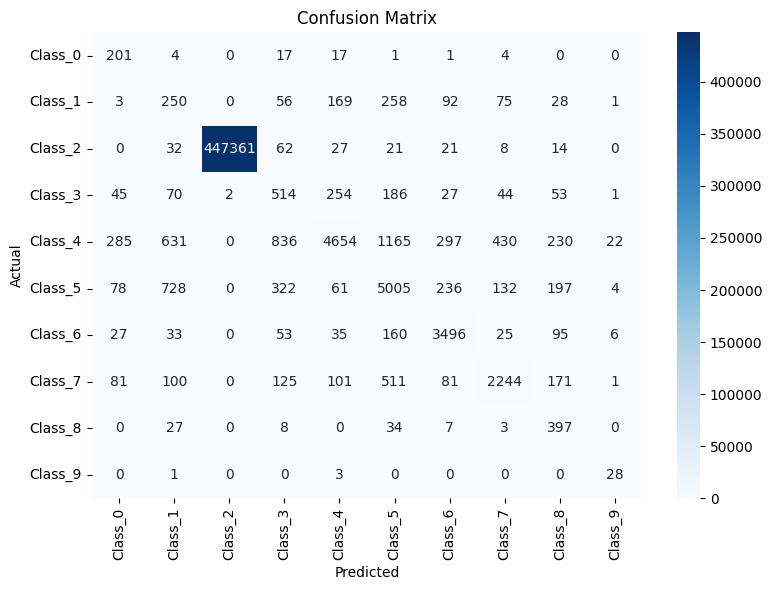


=== CONFIDENCE ANALYSE ===
Durchschnittliche Confidence: 17.0581
Median Confidence: 17.7656
Min Confidence: 1.9238
Max Confidence: 19.1406


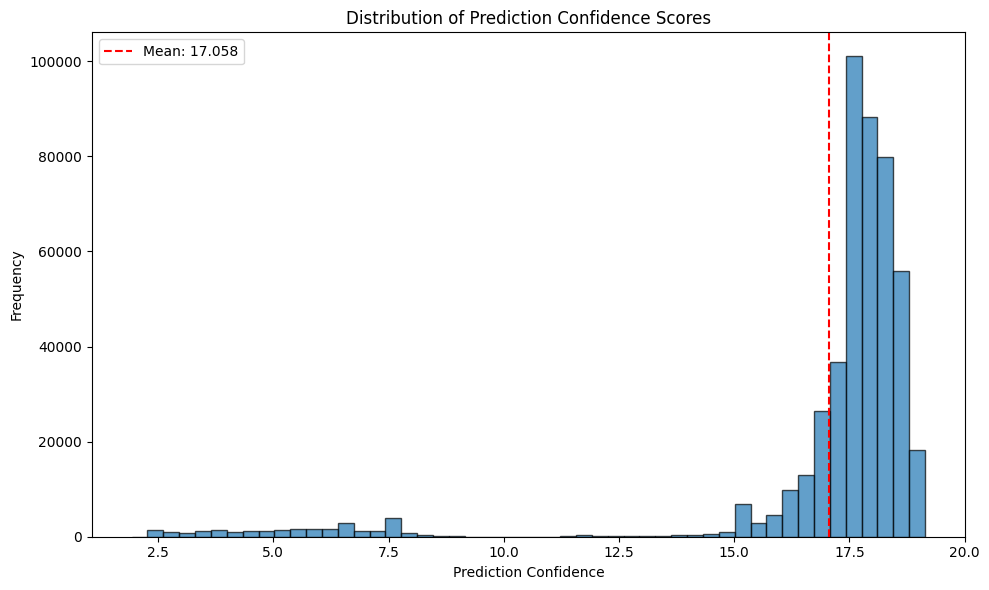

In [ ]:
# Confusion Matrix Visualisierung
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f"Class_{i}" for i in range(num_labels)],
            yticklabels=[f"Class_{i}" for i in range(num_labels)])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Prediction Confidence Analyse
confidence_scores = np.max(predictions.predictions, axis=1)
print(f"\n=== CONFIDENCE ANALYSE ===")
print(f"Durchschnittliche Confidence: {np.mean(confidence_scores):.4f}")
print(f"Median Confidence: {np.median(confidence_scores):.4f}")
print(f"Min Confidence: {np.min(confidence_scores):.4f}")
print(f"Max Confidence: {np.max(confidence_scores):.4f}")

# Confidence Histogramm
plt.figure(figsize=(10, 6))
plt.hist(confidence_scores, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Prediction Confidence')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Confidence Scores')
plt.axvline(np.mean(confidence_scores), color='red', linestyle='--', label=f'Mean: {np.mean(confidence_scores):.3f}')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Speichern des Modells und der Ergebnisse

Abschließend werden alle Artefakte des Trainings gespeichert, um eine spätere Verwendung und Reproduzierbarkeit zu gewährleisten:
- Das fein-getunte **Modell** (die Gewichte) und seine **Konfiguration**.
- Der **Tokenizer**.
- Eine Textdatei mit den **Evaluationsergebnissen** und der verwendeten Konfiguration.
- Ein Plot des **Trainingsverlaufs** (Loss und F1-Score über die Epochen).


In [ ]:
def numpy_encoder(obj):
    """ Custom encoder for numpy data types """
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    # Let the base class default method raise the TypeError for other types
    raise TypeError(f"Object of type {obj.__class__.__name__} is not JSON serializable")

def convert_keys_to_str_recursive(obj):
    """
    Recursively traverses a dictionary or list and converts all
    dictionary keys to strings.
    """
    if isinstance(obj, dict):
        return {str(k): convert_keys_to_str_recursive(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_keys_to_str_recursive(elem) for elem in obj]
    else:
        return obj

Speichere Model...

=== MODEL ERFOLGREICH GESPEICHERT ===
Pfad: ./tinybert_finetuned_v7_GAP_no_sep
Enthält:
  - pytorch_model.bin (Model Gewichte)
  - config.json (Model Konfiguration)
  - tokenizer.json (Tokenizer Dateien)
  - eval_results.txt (Evaluation Ergebnisse)
  - label_info.json (Label Informationen)


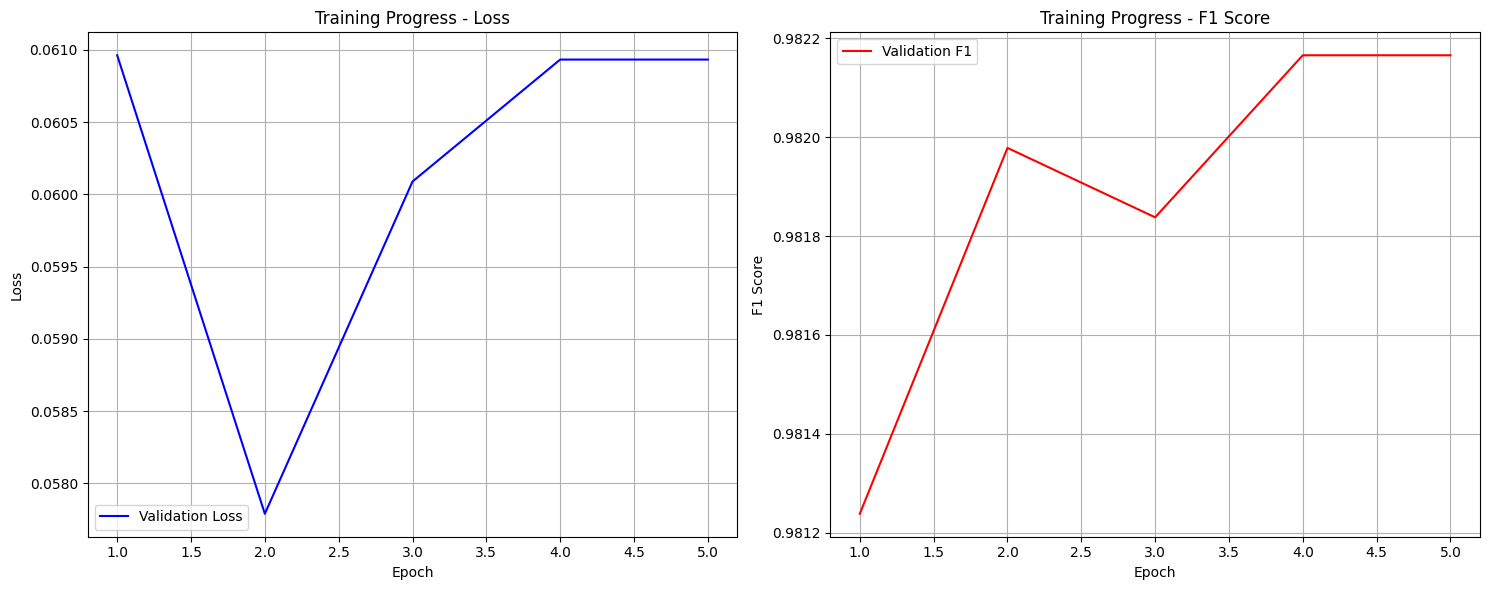

Training History Plot gespeichert in: ./tinybert_finetuned_v7_GAP_no_sep/training_history.png


In [ ]:
# Best Model speichern
print("Speichere Model...")
trainer.save_model(CONFIG['OUTPUT_DIR'])
tokenizer.save_pretrained(CONFIG['OUTPUT_DIR'])

# Evaluation Ergebnisse speichern
results_file = os.path.join(CONFIG['OUTPUT_DIR'], 'eval_results.txt')
with open(results_file, 'w') as f:
    f.write("=== FINALE EVALUATION ERGEBNISSE ===\n")
    for key, value in eval_results.items():
        f.write(f"{key}: {value:.4f}\n")
    
    f.write("\n=== TRAINING KONFIGURATION ===\n")
    for key, value in CONFIG.items():
        f.write(f"{key}: {value}\n")

# Label Mapping speichern (für Referenz)
label_info = {
    'num_labels': num_labels,
    'unique_labels': list(np.unique(train_labels)),
    'label_counts': dict(Counter(train_labels))
}

import json
# Create a new dictionary with keys converted to strings.
label_info_serializable = convert_keys_to_str_recursive(label_info)

with open(os.path.join(CONFIG['OUTPUT_DIR'], 'label_info.json'), 'w') as f:
    json.dump(label_info_serializable, f, indent=2, default=numpy_encoder)

print(f"\n=== MODEL ERFOLGREICH GESPEICHERT ===")
print(f"Pfad: {CONFIG['OUTPUT_DIR']}")
print(f"Enthält:")
print(f"  - pytorch_model.bin (Model Gewichte)")
print(f"  - config.json (Model Konfiguration)")
print(f"  - tokenizer.json (Tokenizer Dateien)")
print(f"  - eval_results.txt (Evaluation Ergebnisse)")
print(f"  - label_info.json (Label Informationen)")

# Training History Plot (falls verfügbar)
if hasattr(trainer.state, 'log_history'):
    log_history = trainer.state.log_history
    
    train_losses = [log['train_loss'] for log in log_history if 'train_loss' in log]
    eval_losses = [log['eval_loss'] for log in log_history if 'eval_loss' in log]
    eval_f1s = [log['eval_f1'] for log in log_history if 'eval_f1' in log]
    
    if train_losses and eval_losses:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Loss Plot
        epochs = range(1, len(eval_losses) + 1)
        ax1.plot(epochs, eval_losses, 'b-', label='Validation Loss')
        ax1.set_title('Training Progress - Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        ax1.grid(True)
        
        # F1 Plot
        if eval_f1s:
            ax2.plot(epochs, eval_f1s, 'r-', label='Validation F1')
            ax2.set_title('Training Progress - F1 Score')
            ax2.set_xlabel('Epoch')
            ax2.set_ylabel('F1 Score')
            ax2.legend()
            ax2.grid(True)
        
        plt.tight_layout()
        plt.savefig(os.path.join(CONFIG['OUTPUT_DIR'], 'training_history.png'), dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"Training History Plot gespeichert in: {CONFIG['OUTPUT_DIR']}/training_history.png")